# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify
meaningful patterns, trends, relationships, and differences in agricultural performance,
and to develop evidence-based conclusions and recommendations.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Explore the Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
print("Seasons present:\n", df['Season'].value_counts())
print("\nCrops present:\n", df['Crop'].value_counts())
print("\nStates covered:", df['State'].nunique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Seasons present:
 Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops present:
 Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

States covered: 8
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 4. Data Cleaning & Preparation

Checking for missing values and duplicates before analysis.

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


Three columns (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`) have a small number
of missing values (<50 each, out of 4000 rows). Since these values are highly season-dependent
(e.g. Kharif and Zaid have very different rainfall patterns), missing values are filled using the
**median of the respective season** rather than the overall median — this preserves the
seasonal character of the data instead of diluting it.

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df.groupby('Season')[col].transform('median'))

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [8]:
# Derived metric: Profit margin, useful for economic comparison across seasons
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df[['Season', 'Profit_INR', 'Revenue_INR', 'Profit_Margin_pct']].head()

,Season,Profit_INR,Revenue_INR,Profit_Margin_pct
0,Kharif,-11852,30810,-38.468030
1,Kharif,-451950,40401,-1118.660429
2,Rabi,-124744,190466,-65.494104
3,Kharif,-95704,200740,-47.675600
4,Zaid,-144352,193607,-74.559288


## 5. Season-wise Performance Summary

Comparing the key performance indicators (yield, profit, water efficiency, disease/pest risk)
across the three seasons.

In [9]:
season_order = ['Kharif', 'Rabi', 'Zaid']

summary = df.groupby('Season')[[
    'Yield_Tonnes_Ha', 'Profit_INR', 'Profit_Margin_pct',
    'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
    'Rainfall_mm', 'Avg_Temperature_C', 'Fertilizer_kg_ha', 'Water_Used_m3'
]].mean().reindex(season_order)

summary.round(2)

,Yield_Tonnes_Ha,Profit_INR,Profit_Margin_pct,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm,Avg_Temperature_C,Fertilizer_kg_ha,Water_Used_m3
Season,,,,,,,,,
Kharif,5.63,178914.65,-38.64,5.89,54.47,852.11,28.45,187.08,6102.20
Rabi,5.04,87689.47,-44.27,5.19,40.48,435.94,23.49,185.41,5846.99
Zaid,4.64,-24804.82,-69.35,4.41,38.22,299.12,31.04,184.64,6419.89


**Observation:** Kharif shows the highest average yield and water efficiency, but also the highest disease/pest risk. Zaid has the lowest yield and the steepest average profit margin loss, likely reflecting higher heat stress and lower rainfall support during that season.

## 6. Yield Distribution by Season

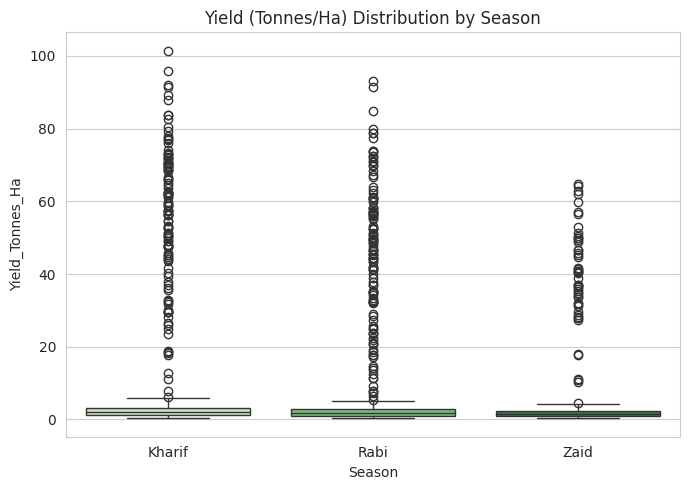

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, hue='Season',
            palette='Greens', legend=False)
plt.title('Yield (Tonnes/Ha) Distribution by Season')
plt.tight_layout()
plt.show()

Kharif shows both the highest median yield and the widest spread, suggesting greater variability in outcomes — likely due to its dependence on monsoon rainfall, which is less predictable than irrigation-supported Rabi cultivation.

## 7. Profit Distribution by Season

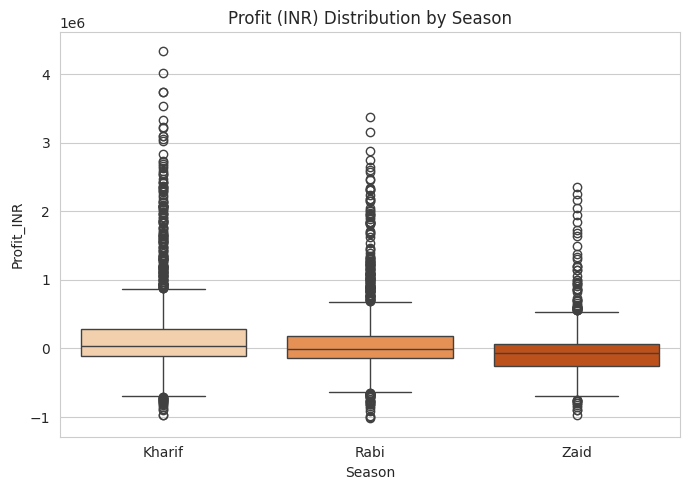

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=season_order, hue='Season',
            palette='Oranges', legend=False)
plt.title('Profit (INR) Distribution by Season')
plt.tight_layout()
plt.show()

In [12]:
print("Average profit margin (%) by season:")
print(df.groupby('Season')['Profit_Margin_pct'].mean().reindex(season_order).round(2))

Average profit margin (%) by season:
Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


**Key finding:** Average profit margin is *negative* across all three seasons, with Zaid performing worst (~-69%), followed by Rabi (~-44%) and Kharif (~-39%). This indicates that, on average across this sample, production costs exceed revenue in every season — a significant and somewhat unexpected pattern worth flagging as a recommendation area.

## 8. Multi-Metric Season Comparison

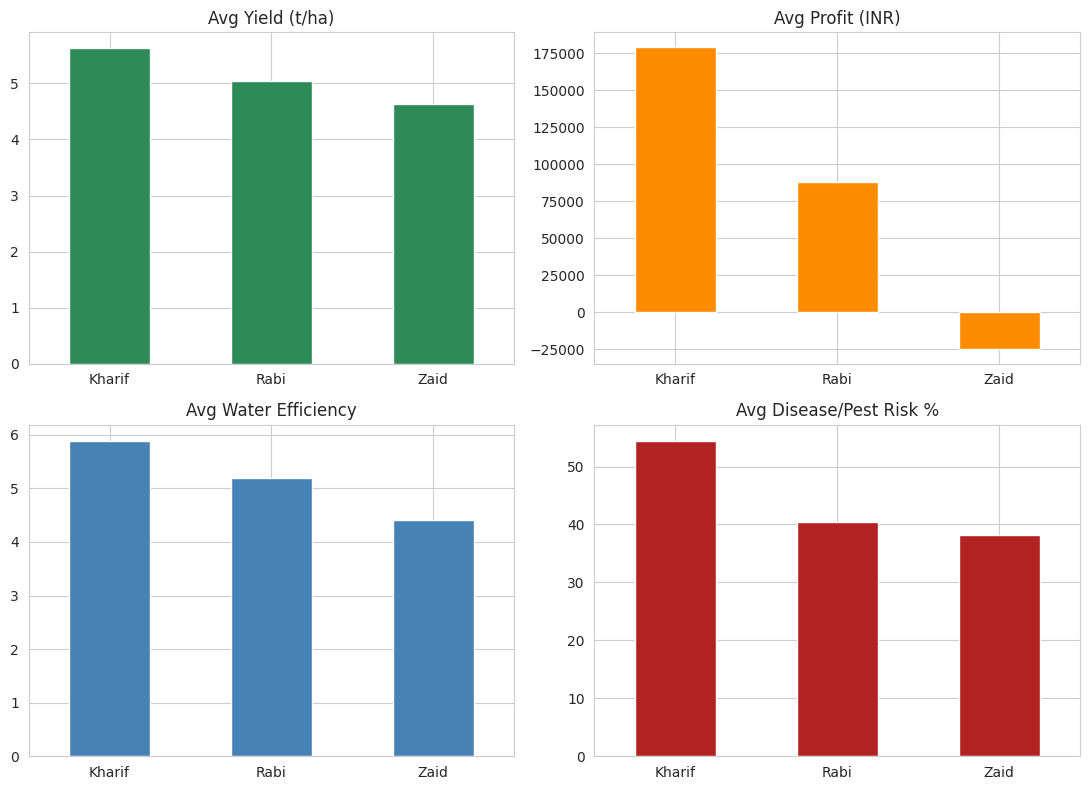

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

summary['Yield_Tonnes_Ha'].plot(kind='bar', ax=axes[0,0], color='seagreen', title='Avg Yield (t/ha)')
summary['Profit_INR'].plot(kind='bar', ax=axes[0,1], color='darkorange', title='Avg Profit (INR)')
summary['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[1,0], color='steelblue', title='Avg Water Efficiency')
summary['Disease_Pest_Risk_pct'].plot(kind='bar', ax=axes[1,1], color='firebrick', title='Avg Disease/Pest Risk %')

for ax in axes.flat:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 9. Relationships Between Environmental Conditions & Performance

Examining correlations between environmental/resource variables and outcomes.

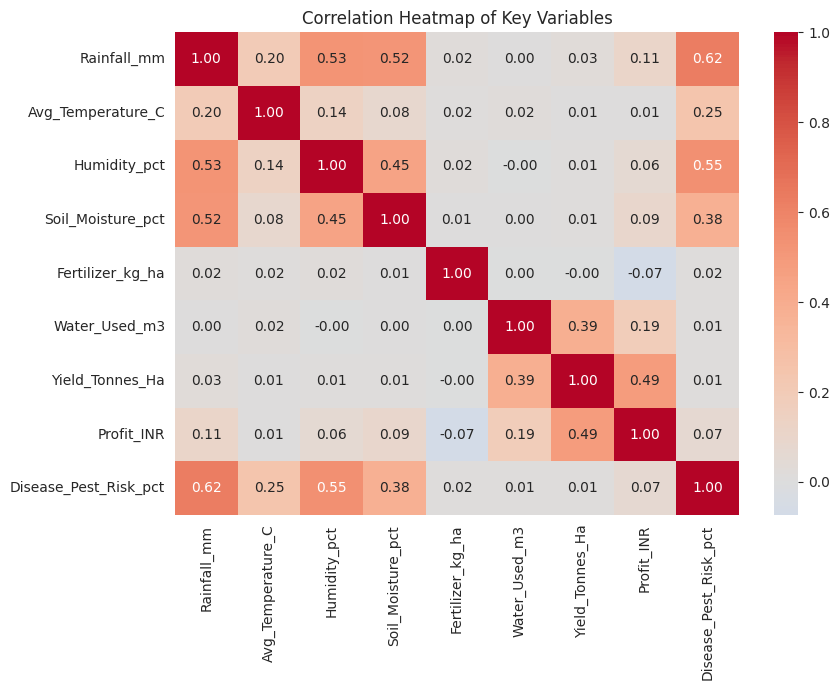

In [14]:
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR',
            'Disease_Pest_Risk_pct']

plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.show()

**Observation:** Correlations between individual environmental variables (rainfall, fertilizer use) and yield are weak in this dataset when examined in isolation — this suggests yield is driven by a *combination* of factors (soil quality, seed quality, irrigation method, crop type) rather than any single variable, which is itself a useful finding: seasonal performance differences are systemic, not caused by one factor alone.

## 10. Rainfall vs Yield, by Season

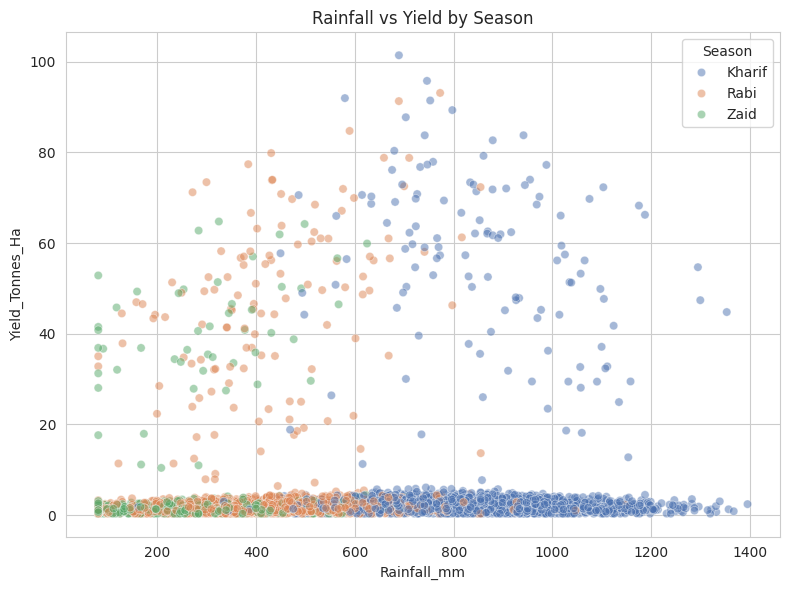

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                hue_order=season_order, alpha=0.5, palette='deep')
plt.title('Rainfall vs Yield by Season')
plt.tight_layout()
plt.show()

## 11. Irrigation Method Effectiveness Across Seasons

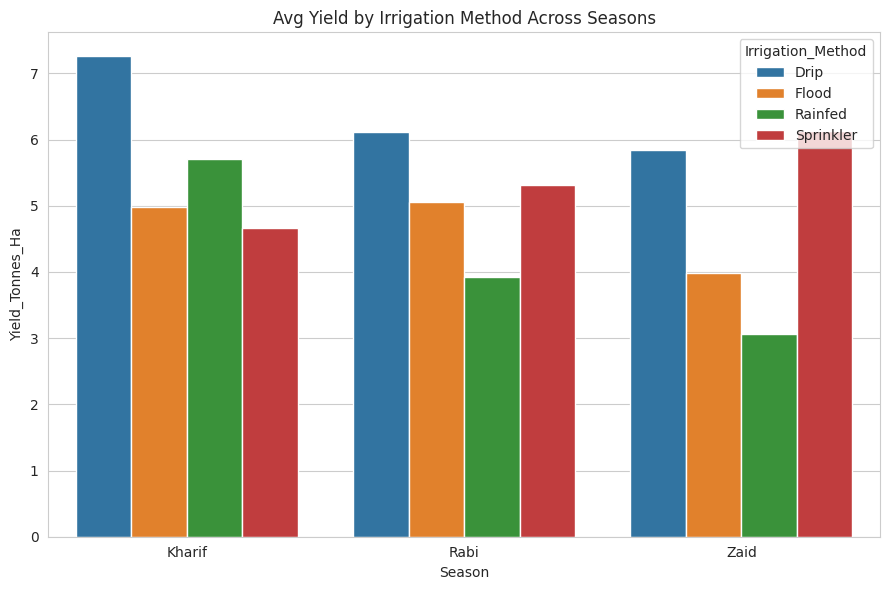

In [16]:
irr = df.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(9,6))
sns.barplot(data=irr, x='Season', y='Yield_Tonnes_Ha', hue='Irrigation_Method', order=season_order)
plt.title('Avg Yield by Irrigation Method Across Seasons')
plt.tight_layout()
plt.show()

Drip irrigation shows a consistent yield advantage in Rabi and Zaid (the drier seasons), while the gap narrows in Kharif where natural rainfall reduces dependency on irrigation method — a pattern that supports targeted irrigation investment recommendations.

## 12. Crop Distribution Across Seasons

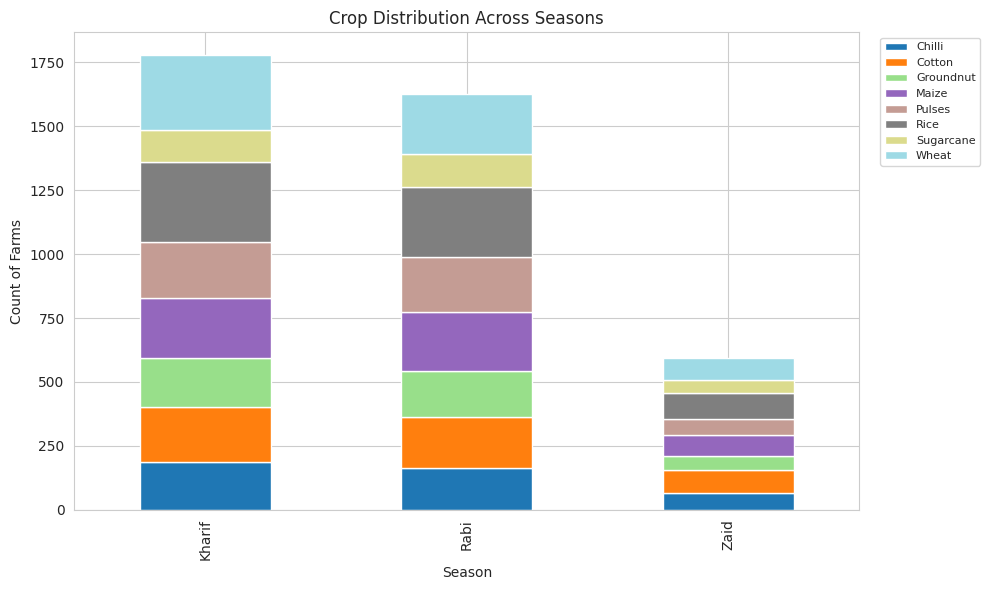

In [17]:
ct = pd.crosstab(df['Season'], df['Crop']).reindex(season_order)

ct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('Crop Distribution Across Seasons')
plt.ylabel('Count of Farms')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 13. Most Profitable Crop per Season

In [18]:
best_crop = (df.groupby(['Season', 'Crop'])['Profit_INR']
             .mean()
             .reset_index()
             .sort_values('Profit_INR', ascending=False)
             .groupby('Season')
             .head(1)
             .reset_index(drop=True))

best_crop

,Season,Crop,Profit_INR
0,Kharif,Sugarcane,1.000791e+06
1,Rabi,Sugarcane,7.316129e+05
2,Zaid,Sugarcane,5.836358e+05


Sugarcane is the most profitable crop on average in every season, though profitability declines from Kharif to Zaid — consistent with the overall seasonal profit trend observed earlier.

## 14. Disease/Pest Risk by Season

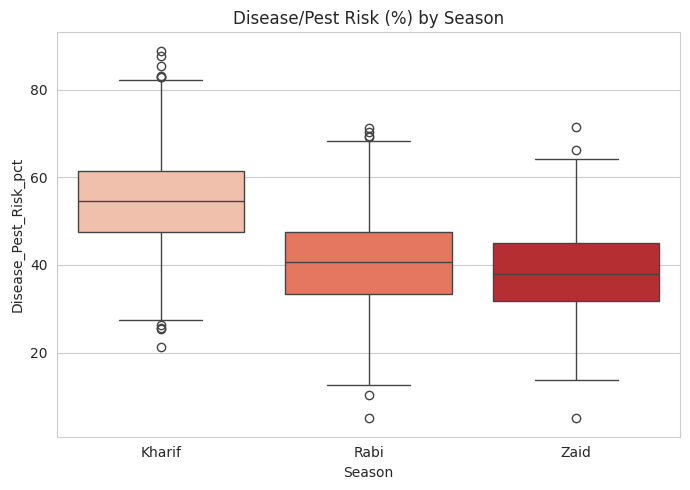

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, hue='Season',
            palette='Reds', legend=False)
plt.title('Disease/Pest Risk (%) by Season')
plt.tight_layout()
plt.show()

Kharif has the highest disease/pest risk on average — expected, since higher humidity and rainfall during monsoon season create favorable conditions for pest and disease outbreaks.

## 15. Key Findings

1. **Yield:** Kharif has the highest average yield (~5.63 t/ha) but also the widest variability;
   Zaid has the lowest average yield (~4.64 t/ha).
2. **Profitability:** Average profit margin is negative across *all* seasons, worsening from
   Kharif (-38.6%) → Rabi (-44.3%) → Zaid (-69.4%). This is the most striking finding — costs
   are outpacing revenue across the board, and the problem intensifies in the dry Zaid season.
3. **Water efficiency:** Kharif farms use water most efficiently (5.89 t per 1000 m³), while
   Zaid is least efficient (4.41), likely due to higher irrigation dependency in a hotter, drier
   season.
4. **Disease/pest risk:** Highest in Kharif (~54%) due to monsoon humidity, lowest in Zaid (~38%).
5. **Irrigation method:** Drip irrigation gives a consistent yield edge in Rabi and Zaid; the
   advantage shrinks in Kharif when rainfall itself supplies moisture.
6. **Crop economics:** Sugarcane is the most profitable crop in every season, but its margin
   still shrinks moving from Kharif to Zaid — showing the seasonal effect holds even for the
   best-performing crop.
7. **Single-factor correlations are weak:** No single environmental variable (rainfall,
   fertilizer) strongly predicts yield alone — performance is driven by a combination of
   conditions, not one dominant factor.

## 16. Recommendations

- **Address the profitability gap:** Since average profit margins are negative in every season,
  cost structures (fertilizer, pesticide, water, labor) need review — particularly for Zaid,
  where margins are worst.
- **Expand drip irrigation** in Rabi and Zaid seasons where it shows the clearest yield benefit,
  to improve water efficiency and reduce costs simultaneously.
- **Targeted pest management for Kharif:** Given the elevated disease/pest risk during monsoon,
  proactive pest control measures should be prioritized in that season specifically.
- **Promote higher-margin crops** like Sugarcane where regional and water conditions allow,
  especially in seasons with otherwise weak profitability.
- **Further investigation:** A deeper regional (state/district) breakdown would help identify
  whether the profitability issue is uniform or concentrated in specific areas, which is a
  natural next step for this analysis.